In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

%matplotlib inline 


In [5]:
df = pd.read_csv('weight-height.csv')

In [6]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


Text(0, 0.5, 'Height')

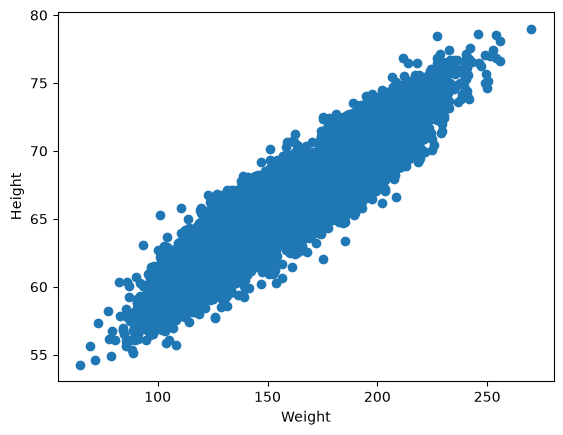

In [7]:
### scatter plot
plt.scatter(df['Weight'], df['Height'])

plt.xlabel('Weight')
plt.ylabel('Height')

### we can see that there is a linear relationship is building because as weight is increasing then height is also increasing with that and vice versa 

In [8]:
# finding corelation

df.corr(numeric_only=True)

,Height,Weight
Height,1.000000,0.924756
Weight,0.924756,1.000000


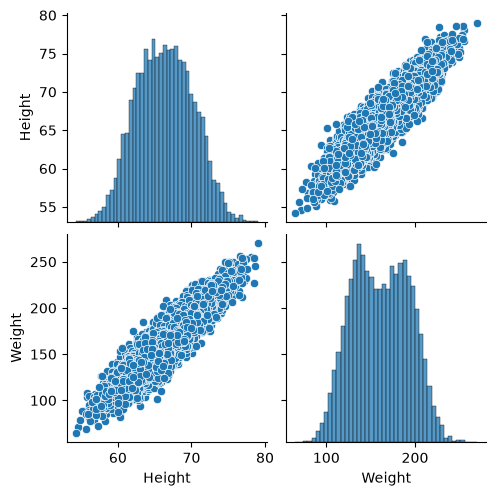

In [9]:
sns.pairplot(df)

In [10]:
## Lets start with simple linear regression

# so lets differentiate features into independent and dependent features

df.head() 



,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [11]:
# Independent Feature (X) -> DataFrame (2D)
X = df[['Height']]   # ya df[['Weight']]
# Dependent Feature (y) -> Series (1D)
y = df['Weight']     # ya df['Height']


## Train Test split helps detect overfitting and underfitting
## Train dataset: Used for training (learning) the model
## Test dataset: Used for checking/evaluating how the model predicts on new, unseen data


In [12]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.25)

In [13]:
X_train.shape

(7500, 1)

## Next step is standardization

**Standardization** aur **Z-Score** ka concept bohot hi simple aur interesting hai. Chaliye isko bilkul aasan real-life example se samajhte hain:

---

### 1. Z-Score ka Formula:
$$z = \frac{x - \mu}{\sigma}$$

Jahan:
- $x$ = Aapka actual data point (jaise kisi ki Height: $70\text{ inches}$)
- $\mu$ (Mu) = **Mean** (Average)
- $\sigma$ (Sigma) = **Standard Deviation** (Data ka phailav / spread)

---

### 2. "Mean = 0" ka matlab kya hai?

Maan lijiye 3 doston ke marks hain: **`50, 60, 70`**
- Inka **Mean (Average)** hoga: $\frac{50 + 60 + 70}{3} = \mathbf{60}$

Ab agar hum har ek ke marks me se Mean ($60$) minus kar dein:
- $50 - 60 = \mathbf{-10}$ (Average se kam)
- $60 - 60 = \mathbf{0}$ (Bilkul average par)
- $70 - 60 = \mathbf{+10}$ (Average se zyada)

Ab in nayi values $(-10, 0, +10)$ ka average nikalenge toh:
$$\frac{-10 + 0 + 10}{3} = \mathbf{0}$$

👉 **Matlab:** Har value me se mean minus karne par **data ka center (average) $0$ par shift ho jata hai.**  
- **$0$** ka matlab: Data bilkul average par hai.
- **Positive ($+$)** ka matlab: Data average se upar hai.
- **Negative ($-$)** ka matlab: Data average se neeche hai.

---

### 3. "Standard Deviation = 1" ka matlab kya hai?

Standard Deviation batata hai ki **"data center se kitna phaila (spread out) hua hai"**.

Jab hum values ko $\sigma$ (Standard Deviation) se divide kar dete hain:
- Data ka phailav (spread) shrink hokar **$1$ unit** ke scale par set ho jata hai.
- Iska sabse bada fayda ye hota hai ki **units (inches, cm, kg, lbs) khatam ho jati hain**.
- Ab number ka matlab hota hai: *"Ye value average se kitne standard deviation door hai?"*
  - $z = +1.5$ $\rightarrow$ Average se 1.5 standard deviation upar
  - $z = -2.0$ $\rightarrow$ Average se 2 standard deviation neeche

---

### 4. ML me hum ye kyu karte hain? (Main Reason)

Sochiye aapke paas do features hain:
1. **Age:** $20$ se $60$ (Chhote numbers)
2. **Salary:** $25,000$ se $2,00,000$ (Bohot bade numbers)

Machine Learning algorithms (jaise Gradient Descent) bade numbers (Salary) ko dekh kar confuse ho jate hain aur sochte hain ki Salary bohot zyada important feature hai, jabki Age bechari ignore ho jati hai.

**Standardization karne se:**
Dono features ka Mean $0$ aur Standard Deviation $1$ ban jata hai (dono $-3$ se $+3$ ki range ke aas-paas aa jate hain). Isse dono features ko **barabar ki izzat** milti hai aur model bohot tezi se aur accurately train hota hai!

---

### 💡 Code me sir ye karenge:
```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Training data ko fit aur transform karte hain
X_train = scaler.fit_transform(X_train)

# Test data ko sirf transform karte hain (data leakage se bachne ke liye)
X_test = scaler.transform(X_test)
```


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Training data ko fit aur transform karte hain
X_train = scaler.fit_transform(X_train)

# Test data ko sirf transform karte hain (data leakage se bachne ke liye)
X_test = scaler.transform(X_test)

X_test


array([[-1.03895701],
       [ 1.20713637],
       [-1.0480164 ],
       ...,
       [ 0.41455192],
       [-0.54541013],
       [ 1.44356665]], shape=(2500, 1))

In [15]:
# applying simple linear regression

from sklearn.linear_model import LinearRegression

regression = LinearRegression(n_jobs=-1)

regression.fit(X_train, y_train)


,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[29.77]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,161.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[86.6]


In [16]:
print("Coefficient or slope:", regression.coef_)
print("Intercept: ", regression.intercept_)

Coefficient or slope: [29.77395388]
Intercept:  161.69148649976094


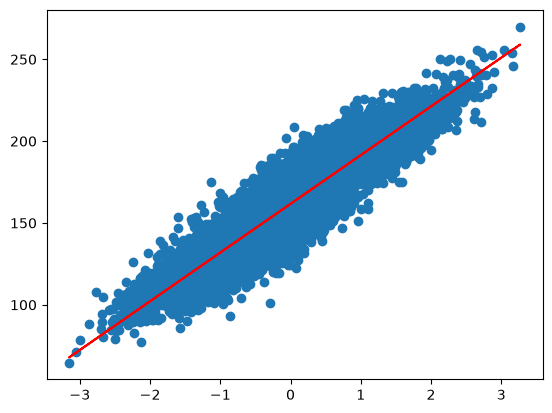

In [17]:
## plot training data plot best fit line

plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), color="red")

## prediction of test data

1. predicted Height output = intercept + coef_(Weights)
2. y_pred_test=156.470 + 17.29(X_test)

In [18]:
y_pred = regression.predict(X_test)

In [19]:
# performance metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [20]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(mse)
print(mae)
print(rmse)

146.75356139886432
9.6166192436162
12.11418843335633



---

### 1. Best Fit Line ka Code kya kar raha hai?

```python
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train))
```

- **`plt.scatter(X_train, y_train)`:**  
  - Ye aapka **Actual Data Points** (dots) draw karta hai.  
  - $X$-axis par training height, aur $Y$-axis par training weight.
- **`plt.plot(X_train, regression.predict(X_train))`:**  
  - `plt.plot()` points ke beech me **line** draw karta hai.
  - Isme $X$-axis toh `X_train` hai, lekin $Y$-axis par humne `y_train` (actual) nahi diya, balki **`regression.predict(X_train)`** diya.
  - `regression.predict(X_train)` ka matlab: Model ne $y = mx + c$ formula se jo **predicted straight line values** calculate ki hain, unhe plot karo. Isiliye ye ek seedhi **Best Fit Line** bankar aati hai.

---

### 2. Best Fit Line ka Color Red kaise karein?

Aap bilkul sahi keh rahe hain! Blue dots par blue line chup jati hai. Aap `color='red'` aur `linewidth=3` use karke line ko ekdum clear aur bold dikha sakte hain:

```python
plt.scatter(X_train, y_train)

# color='red' aur linewidth badha di taaki saaf dikhe
plt.plot(X_train, regression.predict(X_train), color='red', linewidth=3)

plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Best Fit Line on Training Data')
plt.show()
```

---

### 3. Prediction on Test Data (`y_pred = regression.predict(X_test)`)

```python
y_pred = regression.predict(X_test)
```

- **`X_test`:** Ye wo 25% data hai jo model ne **aaj tak kabhi nahi dekha** (Exam ka unseen question paper).
- **`regression.predict(X_test)`:** Humne model ko sirf `X_test` (Heights) di, aur model ne apne seekhe hue formula ($y = mx + c$) se unka Weight predict kiya.
- **`y_pred`:** Model ke dwara diye gaye **Predicted Answers ($\hat{y}$)** is variable me store ho gaye.
- *(Notice karein ki humne model ko `y_test` nahi diya! Ab hum `y_pred` aur actual `y_test` ko compare karke dekhenge ki model ne exam me kitni galtiyan ki hain).*

---

### 4. Error ke saare types kyu nikaal rahe hain? RMSE acha kyu hai?

Error ka basic formula hota hai:  
$$\text{Error} = \text{Actual } (y) - \text{Predicted } (\hat{y})$$

Sir teeno isliye nikaal rahe hain kyunki teeno ka apna ek alag maqsad hota hai:

| Metric | Formula | Fayda | Kami |
| :--- | :--- | :--- | :--- |
| **MAE** (Mean Absolute Error) | $\frac{1}{n}\sum \|y - \hat{y}\|$ | Samjhne me sabse aasan hai (e.g., *"Model on average 5 lbs ki galti kar raha hai"*). | Badi galtiyon (outliers) ko zyada punish nahi karta. |
| **MSE** (Mean Squared Error) | $\frac{1}{n}\sum (y - \hat{y})^2$ | Badi galtiyon ko square karke **bohot zyada punish** karta hai ($10$ ka error seedha $100$ ban jata hai). | Iski unit square ho jati hai ($\text{lbs}^2$), jo real life me samajh nahi aati. |
| **RMSE** (Root Mean Squared Error) | $\sqrt{\text{MSE}}$ | **Sabse Best!** Dono ka fayda milta hai: 1. Outliers ko punish bhi karta hai. 2. Square root lene se unit wapas normal ($\text{lbs}$) me aa jati hai. | — |

#### ❓ Phir teeno kyu calculate kiye?
1. **Outliers Check Karne ke Liye:**  
   Agar aapka **RMSE, MAE se bohot bada aa raha hai**, iska matlab aapke data me kuch aise points hain jahan model bohot badi galtiyan (huge errors) kar raha hai.
2. **Interview & Sir ka Reason:**  
   Sir teeno isliye sikha rahe hain taaki aapko teeno ka farak samajh aaye, par **real projects me 90% log RMSE aur $R^2$ Score hi dekhte hain!**

---

### 1. $R^2$ (R Square / Coefficient of Determination) kya hai?

#### 📐 Formula:
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

Jahan:
- $SS_{res}$ (**Residual Sum of Squares**): Aapke Regression Model ne kitni galtiyan ki.
- $SS_{tot}$ (**Total Sum of Squares**): Ek bilkul simple **Average Line (Mean $\bar{y}$)** ne kitni galtiyan ki.

#### 💡 Aasan Shabdon me Matlab:
$R^2$ ye batata hai ki:
> **"Aapke Independent Feature (Height) ne Dependent Feature (Weight) ke variation ko kitne percent explain kiya?"**

Aapke notebook me output aaya hai: **`0.856`**  
👉 Iska matlab: **85.6% variation** Height ki wajah se explain ho raha hai! Bacha hua 14.4% noise ya dusre factors hain. $R^2$ jitna $1$ ke paas ho, model utna hi shandaar hota hai!

---

### 2. $R^2$ aur Adjusted $R^2$ dono kyu nikaal rahe hain? Aur dono same kyu aa rahe hain?

#### ❓ Problem with $R^2$:
$R^2$ ki ek bohot buri aadat hoti hai:
- Agar aap dataset me koi **faltu/useless column** bhi daal do (jaise bache ka *"Shoe Size"* ya *"Phone Number"*), tab bhi **$R^2$ kabhi kam nahi hota** — ya toh badhta hai ya same rehta hai.
- Toh koi bhi cheating karke faltu features add karke $R^2$ badha sakta hai.

#### ✅ Solution: Adjusted $R^2$
$$\text{Adjusted } R^2 = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - p - 1} \right]$$
*(Jahan $n$ = Total rows, $p$ = Number of features)*

- Agar feature **kaam ka hai** $\rightarrow$ Adjusted $R^2$ badhega.
- Agar feature **faltu hai** $\rightarrow$ Adjusted $R^2$ **penalize karke kam ho jayega!**

#### ❓ Dono ka score same kyu aa raha hai (`0.8560` vs `0.8559`)?
Kyunki abhi aap **Simple Linear Regression** kar rahe hain:
1. Aapke paas sirf **1 feature ($p = 1$)** hai (`Height`).
2. Data points ($n$) bohot zyada hain ($2500$ rows).

Jab $p = 1$ aur $n$ bohot bada ho, toh $\frac{n - 1}{n - p - 1} \approx 1$ ho jata hai, isliye dono lagbhag same aate hain. Aage chal kar jab **Multiple Linear Regression** me 10-15 features aayenge, tab dono me bada farak dikhega!

---

### 3. OLS (Ordinary Least Squares) kya hai aur kyu use kar rahe hain?

- **`sklearn` ka `LinearRegression`:** Ye sirf **Machine Learning predictions** ke liye bana hai (ye sirf slope aur intercept deta hai, koi detailed explanation nahi deta).
- **`statsmodels` ka `OLS`:** Ye **Statistical Analysis** ke liye bana hai.
  - Jab aap `print(model.summary())` karte hain, toh ye pura **Doctor ki Blood Report** jaisa table deta hai:
    - **p-value** (feature sach me zaroori hai ya kismat se correlation aa gaya).
    - **t-statistic**, **F-statistic**.
    - Confidence Intervals, Skewness, Kurtosis.
  - Data scientists model ki statistical credibility prove karne ke liye OLS summary nikaalte hain.

---

### 4. Cell `X35` me Error kyu aa rahi hai?
*(Code: `model = sm.OLS(y_train, X_train).fit()`)*

Aapke notebook ke error traceback me likha hai:
> **`NameError: name 'y_train' is not defined`**

#### 🔍 Wajah:
Aapka Jupyter notebook ka **Kernel restart ho gaya tha**, aur aapne upar wali cells (`train_test_split` wali cell) ko run kiye bina seedha ye cell run kar di! Isliye Python ko pata hi nahi chala ki `y_train` aur `X_train` kya hain.

#### 🛠️ Solution:
Upar se notebook ki saari cells ko dobara sequentially run kar lijiye (`Shift + Enter` karke), error chali jayegi!

---

### 5. Cell `X34` me baad me kya hua hai?
```python
prediction = model.predict(X_test)
print(prediction)

print(model.summary())
```
1. **`prediction = model.predict(X_test)`**: Statsmodels OLS model se test data ke liye predictions calculate ki.
2. **`print(model.summary())`**: Pura statistical summary scorecard display karwaya (jisme $R^2$, p-values, aur standard errors ka pura table aata hai).

---

### 6. Cell `X40` me sir ne kya kiya? (`regression.predict(...)`)

Sir ne **ek naye bande ka Weight predict kiya jiski Height = 72 inches hai!**

Samjhein ye kaise kaam kar raha hai:
```python
# Sahi Syntax:
regression.predict(scaler.transform([[72]]))
```

1. **`[[72]]` kyu likha?**  
   Kyunki model ko hamesha 2D array chahiye `(1 sample, 1 feature)`.
2. **`scaler.transform([[72]])` kyu lagaya?**  
   **Bohot zaroori:** Humne model ko standardize kiye hue data ($z$-scores) par train kiya tha! Agar aap seedha 72 bhej doge, toh model use $z$-score = 72 maan lega (jo ki namumkin hai, 72 standard deviations door!). Isliye pehle 72 inches ko scaler ke zariye transform kiya, aur fir model ne uska accurate weight predict kiya.

*(Note: Code me `scaler.transform[[72]]` ki jagah round brackets `scaler.transform([[72]])` honge).*

In [21]:
# now finding R square
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print(score)


0.855093761341282


In [22]:
# then adjust r square

1 - (1-score) * (len(y_test) -1) / (len(y_test) - X_test.shape[1] -1)

0.8550357524386965

In [23]:
import statsmodels.api as sm 

model = sm.OLS(y_train, X_train).fit()

In [24]:
prediction = model.predict(X_test)
print(prediction)

print(model.summary())

[-30.93385796  35.94122265 -31.20359184 ...  12.34284969 -16.2390161
  42.98068699]
                                 OLS Regression Results                                
Dep. Variable:                 Weight   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):              0.032
Method:                 Least Squares   F-statistic:                              252.8
Date:                Sat, 19 Sep 2026   Prob (F-statistic):                    5.15e-56
Time:                        19:03:42   Log-Likelihood:                         -48806.
No. Observations:                7500   AIC:                                  9.761e+04
Df Residuals:                    7499   BIC:                                  9.762e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err    

In [32]:
def predict_weight_in_kg(height_cm):
    # 1. cm ko inches me badlo (1 inch = 2.54 cm)
    height_inches = height_cm / 2.54
    
    # 2. Scaler se transform karo
    scaled_height = scaler.transform([[height_inches]])
    
    # 3. Model se prediction lo (lbs me aayega)
    weight_lbs = regression.predict(scaled_height)[0]
    
    # 4. lbs ko kg me badlo (1 lb = 0.4536 kg)
    weight_kg = weight_lbs * 0.453592
    
    return round(weight_kg, 2)


In [33]:
# prediction for new data

# Aap apni height (cm me) daaliye:
my_height = 160

predicted_weight = predict_weight_in_kg(my_height)
print(f"Aapki Height: {my_height} cm")
print(f"Model ke anusaar aapka Weight hona chahiye: {predicted_weight} kg")


Aapki Height: 160 cm
Model ke anusaar aapka Weight hona chahiye: 61.4 kg


d:\Projects\MachineLearning_Practise\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
